In [1]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

OUT_DIR = "/data/silvija/diffusion_results"
os.makedirs(OUT_DIR, exist_ok=True)

zr_path = os.path.join(OUT_DIR, "zr_features.npy")
xml_path = os.path.join(OUT_DIR, "xml_features_proj.npy")

zr = np.load(zr_path).astype(np.float32)      # [N, 128]
zxml = np.load(xml_path).astype(np.float32)   # [N, 64]

print("zr shape :", zr.shape)
print("zxml shape :", zxml.shape)

assert zr.ndim == 2
assert zxml.ndim == 2
assert zr.shape[0] == zxml.shape[0]

N = zr.shape[0]
zr_len = zr.shape[1]
xml_len = zxml.shape[1]

print("N:", N)
print("zr_len:", zr_len)
print("xml_len:", xml_len)

device: cuda
zr shape : (10000, 128)
zxml shape : (10000, 64)
N: 10000
zr_len: 128
xml_len: 64


In [3]:
class ZXMLZrDataset(Dataset):
    def __init__(self, zxml_array, zr_array):
        self.zxml = torch.tensor(zxml_array, dtype=torch.float32)
        self.zr = torch.tensor(zr_array, dtype=torch.float32)

    def __len__(self):
        return len(self.zxml)

    def __getitem__(self, idx):
        x_xml = self.zxml[idx].unsqueeze(0)   # [1, xml_len]
        y_zr = self.zr[idx].unsqueeze(0)      # [1, zr_len]
        return x_xml, y_zr


full_dataset = ZXMLZrDataset(zxml, zr)

n_train = int(0.8 * len(full_dataset))
n_val = len(full_dataset) - n_train

train_ds, val_ds = random_split(full_dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, drop_last=False)



In [4]:
def mish(x):
    return x * torch.tanh(F.softplus(x))


class Mish(nn.Module):
    def forward(self, x):
        return mish(x)


class Upsample(nn.Module):
    def __init__(self, scale_factor=3):
        super().__init__()
        self.scale_factor = scale_factor

    def forward(self, x):
        return F.interpolate(x, scale_factor=self.scale_factor, mode="nearest")


class ResBlock(nn.Module):
    def __init__(self, in_channel, channel):
        super().__init__()
        self.conv_1 = nn.Conv1d(in_channel, channel, kernel_size=3, padding=1)
        self.conv_2 = nn.Conv1d(channel, in_channel, kernel_size=3, padding=1)

    def forward(self, inp):
        x = self.conv_1(inp)
        x = mish(x)
        x = self.conv_2(x)
        x = x + inp
        return mish(x)


class Encoder1D(nn.Module):
    def __init__(self, in_feat_dim=1, codebook_dim=16, hidden_dim=128, num_res_blocks=2):
        super().__init__()

        blocks = [
            nn.Conv1d(in_feat_dim, hidden_dim // 2, kernel_size=3, stride=3, padding=1),
            Mish(),
            nn.Conv1d(hidden_dim // 2, hidden_dim, kernel_size=3, padding=1),
            Mish(),
        ]

        for _ in range(num_res_blocks):
            blocks.append(ResBlock(hidden_dim, hidden_dim // 2))
            blocks.append(nn.BatchNorm1d(hidden_dim))

        blocks.append(nn.Conv1d(hidden_dim, codebook_dim, kernel_size=1))
        blocks.append(nn.BatchNorm1d(codebook_dim))

        self.blocks = nn.Sequential(*blocks)

    def forward(self, x):
        x = x.float()
        return self.blocks(x)


class Decoder1D(nn.Module):
    def __init__(self, in_feat_dim=16, out_feat_dim=1, hidden_dim=128, num_res_blocks=2):
        super().__init__()

        blocks = [
            nn.Conv1d(in_feat_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            Mish(),
        ]

        for _ in range(num_res_blocks):
            blocks.append(ResBlock(hidden_dim, hidden_dim // 2))
            blocks.append(nn.BatchNorm1d(hidden_dim))

        blocks.extend([
            Upsample(scale_factor=3),
            nn.Conv1d(hidden_dim, hidden_dim // 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim // 2),
            Mish(),
            nn.Conv1d(hidden_dim // 2, out_feat_dim, kernel_size=3, padding=1),
            nn.Tanh(),
        ])

        self.blocks = nn.Sequential(*blocks)

    def forward(self, x):
        x = x.float()
        return self.blocks(x)


class VQCodebook1D(nn.Module):
    def __init__(self, codebook_dim=16, codebook_slots=32, temperature=0.5):
        super().__init__()
        self.codebook_dim = codebook_dim
        self.codebook_slots = codebook_slots
        self.temperature = temperature
        self.log_slots_const = np.log(codebook_slots)

        self.codebook = nn.Embedding(codebook_slots, codebook_dim)

    def ze_to_zq(self, ze, soft=True):
        # ze: [B, C, T]
        bs, feat_dim, t = ze.shape
        assert feat_dim == self.codebook_dim

        ze_perm = ze.permute(0, 2, 1).contiguous()      # [B, T, C]
        z_e_flat = ze_perm.view(bs * t, feat_dim)       # [B*T, C]

        codebook = self.codebook.weight                 # [K, C]
        codebook_sqr = torch.sum(codebook ** 2, dim=1)                # [K]
        z_e_flat_sqr = torch.sum(z_e_flat ** 2, dim=1, keepdim=True)  # [B*T,1]

        distances = torch.addmm(
            codebook_sqr + z_e_flat_sqr,
            z_e_flat,
            codebook.t(),
            alpha=-2.0,
            beta=1.0
        )  # [B*T, K]

        if soft:
            probs = F.softmax(-distances / self.temperature, dim=1)
            hard_indices = torch.argmax(probs, dim=1).view(bs, t)     # [B,T]
            z_q = (probs @ codebook).view(bs, t, feat_dim)            # [B,T,C]

            KL = probs * (torch.log(probs + 1e-9) + self.log_slots_const)
            KL = KL.view(bs, t, self.codebook_slots).sum(dim=(1, 2)).mean()

            commit_loss = (
                probs.view(bs, t, self.codebook_slots)
                * distances.view(bs, t, self.codebook_slots)
            ).sum(dim=(1, 2)).mean()
        else:
            hard_indices = torch.argmin(distances, dim=1).view(bs, t)  # [B,T]
            hard_onehot = F.one_hot(
                hard_indices, num_classes=self.codebook_slots
            ).type_as(codebook).view(bs * t, self.codebook_slots)

            z_q = (hard_onehot @ codebook).view(bs, t, feat_dim)

            probs = F.softmax(-distances, dim=1)
            KL = probs * (torch.log(probs + 1e-9) + self.log_slots_const)
            KL = KL.view(bs, t, self.codebook_slots).sum(dim=(1, 2)).mean()

            commit_loss = torch.tensor(0.0, device=ze.device)

        z_q = z_q.permute(0, 2, 1).contiguous()  # [B,C,T]
        return z_q, hard_indices, KL, commit_loss

    def lookup(self, ids):
        # ids: [B,T]
        codebook = self.codebook.weight
        return F.embedding(ids, codebook).permute(0, 2, 1).contiguous()

    def quantize(self, z_e, soft=False):
        with torch.no_grad():
            z_q, indices, _, _ = self.ze_to_zq(z_e, soft=soft)
        return z_q, indices

    def quantize_indices(self, z_e, soft=False):
        with torch.no_grad():
            _, indices, _, _ = self.ze_to_zq(z_e, soft=soft)
        return indices

    def forward(self, z_e, soft=True):
        return self.ze_to_zq(z_e, soft=soft)



In [5]:
class VQVAE1D(nn.Module):
    def __init__(
        self,
        in_feat_dim=1,
        hidden_dim=128,
        num_res_blocks=2,
        codebook_dim=16,
        codebook_slots=32,
        KL_coeff=0.001,
        CL_coeff=0.0001,
    ):
        super().__init__()

        self.in_feat_dim = in_feat_dim
        self.hidden_dim = hidden_dim
        self.num_res_blocks = num_res_blocks
        self.codebook_dim = codebook_dim
        self.codebook_slots = codebook_slots
        self.KL_coeff = KL_coeff
        self.CL_coeff = CL_coeff

        self.encoder = Encoder1D(
            in_feat_dim=in_feat_dim,
            codebook_dim=codebook_dim,
            hidden_dim=hidden_dim,
            num_res_blocks=num_res_blocks,
        )

        self.decoder = Decoder1D(
            in_feat_dim=codebook_dim,
            out_feat_dim=in_feat_dim,
            hidden_dim=hidden_dim,
            num_res_blocks=num_res_blocks,
        )

        self.codebook = VQCodebook1D(
            codebook_dim=codebook_dim,
            codebook_slots=codebook_slots,
        )
        self.codebook.codebook.weight.data.normal_()

        self.code_count = None
        self.codebook_resets = 0

    def forward(self, x, soft=True):
        target_length = x.shape[-1]

        ze = self.encoder(x)                                   # [B,C,Tq]
        zq, indices, kl_loss, commit_loss = self.codebook(ze, soft=soft)
        x_hat = self.decoder(zq)                               # [B,1,~L]

        if x_hat.shape[-1] != target_length:
            x_hat = F.interpolate(x_hat, size=target_length, mode="linear", align_corners=False)

        return x_hat, ze, zq, indices, kl_loss, commit_loss

    def encode(self, x):
        with torch.no_grad():
            return self.encoder(x)

    def quantize(self, z_e, soft=False):
        return self.codebook.quantize(z_e, soft=soft)

    def decode(self, z_q, target_length=None):
        with torch.no_grad():
            recon = self.decoder(z_q)
            if target_length is not None and recon.shape[-1] != target_length:
                recon = F.interpolate(recon, size=target_length, mode="linear", align_corners=False)
        return recon

    def reconstruct(self, x):
        with torch.no_grad():
            z_e = self.encoder(x)
            z_q, _ = self.codebook.quantize(z_e, soft=False)
            x_hat = self.decoder(z_q)
            if x_hat.shape[-1] != x.shape[-1]:
                x_hat = F.interpolate(x_hat, size=x.shape[-1], mode="linear", align_corners=False)
        return x_hat

    def encode_to_indices(self, x):
        with torch.no_grad():
            z_e = self.encoder(x)
            indices = self.codebook.quantize_indices(z_e, soft=False)
        return indices

    def decode_from_indices(self, indices, target_length):
        with torch.no_grad():
            z_q = self.codebook.lookup(indices)
            x_hat = self.decoder(z_q)
            if x_hat.shape[-1] != target_length:
                x_hat = F.interpolate(x_hat, size=target_length, mode="linear", align_corners=False)
        return x_hat

    @torch.no_grad()
    def reset_least_used_codeword(self, device):
        if self.code_count is None:
            return

        max_count, most_used_code = torch.max(self.code_count, dim=0)
        frac_usage = self.code_count / (max_count + 1e-8)

        z_q_most_used = self.codebook.lookup(most_used_code.view(1, 1).to(device)).squeeze()
        min_frac_usage, min_used_code = torch.min(frac_usage, dim=0)

        reset_factor = float(self.codebook_resets + 1)

        if min_frac_usage < 0.03:
            moved_code = z_q_most_used + torch.randn_like(z_q_most_used) / reset_factor
            self.codebook.codebook.weight.data[min_used_code] = moved_code

        self.code_count.zero_()
        self.codebook_resets += 1



In [6]:
vqvae = VQVAE1D(
    in_feat_dim=1,
    hidden_dim=128,
    num_res_blocks=2,
    codebook_dim=16,
    codebook_slots=32,
    KL_coeff=0.001,
    CL_coeff=0.0001,
).to(device)

vq_optimizer = torch.optim.AdamW(vqvae.parameters(), lr=2e-4, weight_decay=1e-4)


def run_vqvae_epoch(loader, train=True):
    if train:
        vqvae.train()
    else:
        vqvae.eval()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    total_commit = 0.0
    total_count = 0

    if vqvae.code_count is None:
        vqvae.code_count = torch.zeros(vqvae.codebook_slots, device=device, dtype=torch.float64)

    for _, zr_batch in loader:
        zr_batch = zr_batch.to(device)

        with torch.set_grad_enabled(train):
            zr_rec, ze, zq, indices, kl_loss, commit_loss = vqvae(zr_batch, soft=True)

            dims = np.prod(zr_rec.shape[1:])
            recon_loss = F.mse_loss(zr_rec, zr_batch, reduction="none").sum(dim=(1, 2)).mean()

            loss = (
                recon_loss / dims
                + vqvae.KL_coeff * kl_loss / dims
                + vqvae.CL_coeff * commit_loss / dims
            )

            if train:
                vq_optimizer.zero_grad()
                loss.backward()
                vq_optimizer.step()

        indices_onehot = F.one_hot(indices, num_classes=vqvae.codebook_slots).float()
        vqvae.code_count = vqvae.code_count + indices_onehot.sum(dim=(0, 1))

        bs = zr_batch.size(0)
        total_loss += loss.item() * bs
        total_recon += (recon_loss / dims).item() * bs
        total_kl += (kl_loss / dims).item() * bs
        total_commit += (commit_loss / dims).item() * bs
        total_count += bs

    return {
        "loss": total_loss / total_count,
        "recon": total_recon / total_count,
        "kl": total_kl / total_count,
        "commit": total_commit / total_count,
    }


vqvae_best_path = os.path.join(OUT_DIR, "vqvae1d_zr_best.pt")
vqvae_epochs = 200
best_vq_val = float("inf")

train_loss_hist = []
val_loss_hist = []

for epoch in range(1, vqvae_epochs + 1):
    tr = run_vqvae_epoch(train_loader, train=True)
    va = run_vqvae_epoch(val_loader, train=False)

    train_loss_hist.append(tr["loss"])
    val_loss_hist.append(va["loss"])

    print(
        f"[VQVAE] Epoch {epoch:03d} | "
        f"train_loss={tr['loss']:.6f} || "
        f"val_loss={va['loss']:.6f}"
    )

    if va["loss"] < best_vq_val:
        best_vq_val = va["loss"]
        torch.save(vqvae.state_dict(), vqvae_best_path)
        print("Saved VQ-VAE:", vqvae_best_path)

vqvae.load_state_dict(torch.load(vqvae_best_path, map_location=device))
vqvae.eval()



[VQVAE] Epoch 001 | train_loss=0.029672 || val_loss=0.009261
Saved VQ-VAE: /data/silvija/diffusion_results/vqvae1d_zr_best.pt
[VQVAE] Epoch 002 | train_loss=0.004109 || val_loss=0.003883
Saved VQ-VAE: /data/silvija/diffusion_results/vqvae1d_zr_best.pt
[VQVAE] Epoch 003 | train_loss=0.003709 || val_loss=0.003632
Saved VQ-VAE: /data/silvija/diffusion_results/vqvae1d_zr_best.pt
[VQVAE] Epoch 004 | train_loss=0.003508 || val_loss=0.003483
Saved VQ-VAE: /data/silvija/diffusion_results/vqvae1d_zr_best.pt
[VQVAE] Epoch 005 | train_loss=0.003359 || val_loss=0.003351
Saved VQ-VAE: /data/silvija/diffusion_results/vqvae1d_zr_best.pt
[VQVAE] Epoch 006 | train_loss=0.003237 || val_loss=0.003249
Saved VQ-VAE: /data/silvija/diffusion_results/vqvae1d_zr_best.pt
[VQVAE] Epoch 007 | train_loss=0.003126 || val_loss=0.003108
Saved VQ-VAE: /data/silvija/diffusion_results/vqvae1d_zr_best.pt
[VQVAE] Epoch 008 | train_loss=0.003021 || val_loss=0.003023
Saved VQ-VAE: /data/silvija/diffusion_results/vqvae1d_zr_

VQVAE1D(
  (encoder): Encoder1D(
    (blocks): Sequential(
      (0): Conv1d(1, 64, kernel_size=(3,), stride=(3,), padding=(1,))
      (1): Mish()
      (2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (3): Mish()
      (4): ResBlock(
        (conv_1): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (conv_2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      )
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ResBlock(
        (conv_1): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (conv_2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      )
      (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): Conv1d(128, 16, kernel_size=(1,), stride=(1,))
      (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (decoder): Decoder1D(
    (blocks): Sequenti

In [7]:
def collect_tokenized_dataset(loader, model):
    all_xml = []
    all_zr = []
    all_tokens = []

    model.eval()
    with torch.no_grad():
        for zxml_batch, zr_batch in loader:
            zxml_batch = zxml_batch.to(device)
            zr_batch = zr_batch.to(device)

            token_ids = model.encode_to_indices(zr_batch)   # [B, Tq]

            all_xml.append(zxml_batch.cpu())
            all_zr.append(zr_batch.cpu())
            all_tokens.append(token_ids.cpu())

    all_xml = torch.cat(all_xml, dim=0)
    all_zr = torch.cat(all_zr, dim=0)
    all_tokens = torch.cat(all_tokens, dim=0)

    return all_xml, all_zr, all_tokens


train_xml, train_zr, train_tokens = collect_tokenized_dataset(train_loader, vqvae)
val_xml, val_zr, val_tokens = collect_tokenized_dataset(val_loader, vqvae)

print("train_tokens shape:", train_tokens.shape)
print("val_tokens shape:", val_tokens.shape)

token_len = train_tokens.shape[1]
num_codebook_tokens = vqvae.codebook.codebook_slots
BOS_ID = num_codebook_tokens
VOCAB_SIZE = num_codebook_tokens + 1


train_tokens shape: torch.Size([8000, 43])
val_tokens shape: torch.Size([2000, 43])


In [8]:
class TransformerTokenDataset(Dataset):
    def __init__(self, zxml_tensor, zr_tensor, token_tensor, bos_id):
        self.zxml = zxml_tensor.float()
        self.zr = zr_tensor.float()
        self.tokens = token_tensor.long()
        self.bos_id = bos_id

    def __len__(self):
        return len(self.zxml)

    def __getitem__(self, idx):
        zxml = self.zxml[idx]        # [1, xml_len]
        zr = self.zr[idx]            # [1, zr_len]
        tokens = self.tokens[idx]    # [T]

        inp = torch.empty_like(tokens)
        inp[0] = self.bos_id
        inp[1:] = tokens[:-1]

        tgt = tokens
        return zxml, zr, inp, tgt


token_train_ds = TransformerTokenDataset(train_xml, train_zr, train_tokens, BOS_ID)
token_val_ds = TransformerTokenDataset(val_xml, val_zr, val_tokens, BOS_ID)

token_train_loader = DataLoader(token_train_ds, batch_size=128, shuffle=True, drop_last=False)
token_val_loader = DataLoader(token_val_ds, batch_size=128, shuffle=False, drop_last=False)



In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class DecoderBlock(nn.Module):
    def __init__(self, d_model=128, nhead=4, dim_feedforward=256, dropout=0.25):
        super().__init__()

        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True
        )

        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, attn_mask=None):
        h = self.ln1(x)
        attn_out, _ = self.attn(h, h, h, attn_mask=attn_mask, need_weights=False)
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x



In [10]:
class DecoderTransformer(nn.Module):
    def __init__(
        self,
        xml_len,
        vocab_size,
        token_len,
        d_model=128,
        nhead=4,
        num_layers=4,
        dim_feedforward=256,
        dropout=0.25,
    ):
        super().__init__()

        self.xml_len = xml_len
        self.vocab_size = vocab_size
        self.token_len = token_len
        self.d_model = d_model

        self.token_embed = nn.Embedding(vocab_size, d_model)

        self.xml_proj = nn.Sequential(
            nn.Linear(xml_len, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model)
        )

        self.xml_gate = nn.Sequential(
            nn.Linear(xml_len, d_model),
            nn.Sigmoid()
        )

        self.pos = PositionalEncoding(d_model, max_len=token_len + 4)
        self.in_dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            DecoderBlock(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        self.final_ln = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def causal_mask(self, seq_len, device):
        return torch.triu(
            torch.ones(seq_len, seq_len, device=device, dtype=torch.bool),
            diagonal=1
        )

    def forward(self, zxml, input_ids):
        # zxml: [B,1,xml_len]
        # input_ids: [B,T]

        context_vec = zxml.squeeze(1)                 # [B, xml_len]
        context_tok = self.xml_proj(context_vec)      # [B, d_model]
        context_gate = self.xml_gate(context_vec)     # [B, d_model]

        tok_emb = self.token_embed(input_ids)         # [B, T, d_model]
        tok_emb = tok_emb * (1.0 + context_gate.unsqueeze(1))

        context_tok = context_tok.unsqueeze(1)        # [B,1,d_model]

        x = torch.cat([context_tok, tok_emb], dim=1)  # [B,1+T,d_model]
        x = self.pos(x)
        x = self.in_dropout(x)

        mask = self.causal_mask(x.size(1), x.device)

        for block in self.blocks:
            x = block(x, attn_mask=mask)

        x = self.final_ln(x)
        logits = self.lm_head(x)                      # [B,1+T,vocab]
        logits = logits[:, 1:, :]                     # [B,T,vocab]

        return logits

    @torch.no_grad()
    def generate(self, zxml, max_new_tokens, bos_id):
        self.eval()
        B = zxml.size(0)

        generated = torch.full(
            (B, 1),
            bos_id,
            dtype=torch.long,
            device=zxml.device
        )

        for _ in range(max_new_tokens):
            logits = self.forward(zxml, generated)
            next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
            generated = torch.cat([generated, next_token], dim=1)

        return generated[:, 1:]



In [11]:
decodetransformer = DecoderTransformer(
    xml_len=xml_len,
    vocab_size=VOCAB_SIZE,
    token_len=token_len,
    d_model=128,
    nhead=4,
    num_layers=4,
    dim_feedforward=256,
    dropout=0.25,
).to(device)

tr_optimizer = torch.optim.AdamW(
    decodetransformer.parameters(),
    lr=1e-4,
    weight_decay=5e-4
)

tr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    tr_optimizer,
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print(decodetransformer)


DecoderTransformer(
  (token_embed): Embedding(33, 128)
  (xml_proj): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (xml_gate): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): Sigmoid()
  )
  (pos): PositionalEncoding()
  (in_dropout): Dropout(p=0.25, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x DecoderBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.25, inplace=False)
        (3): Linear(in_features

In [12]:
def run_decodetransformer_epoch(loader, train=True):
    if train:
        decodetransformer.train()
    else:
        decodetransformer.eval()

    total_loss = 0.0
    total_count = 0

    for zxml_batch, _, inp_ids, tgt_ids in loader:
        zxml_batch = zxml_batch.to(device)
        inp_ids = inp_ids.to(device)
        tgt_ids = tgt_ids.to(device)

        with torch.set_grad_enabled(train):
            logits = decodetransformer(zxml_batch, inp_ids)

            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                tgt_ids.reshape(-1),
                label_smoothing=0.05
            )

            if train:
                tr_optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(decodetransformer.parameters(), max_norm=1.0)
                tr_optimizer.step()

        bs = zxml_batch.size(0)
        total_loss += loss.item() * bs
        total_count += bs

    return {"loss": total_loss / total_count}


decodetransformer_best_path = os.path.join(OUT_DIR, "decodetransformer_best.pt")

transformer_epochs = 260
best_tr_val = float("inf")
best_epoch = -1
patience = 12
wait = 0

tr_train_loss_hist = []
tr_val_loss_hist = []

for epoch in range(1, transformer_epochs + 1):
    tr = run_decodetransformer_epoch(token_train_loader, train=True)
    va = run_decodetransformer_epoch(token_val_loader, train=False)

    tr_train_loss_hist.append(tr["loss"])
    tr_val_loss_hist.append(va["loss"])

    tr_scheduler.step(va["loss"])
    current_lr = tr_optimizer.param_groups[0]["lr"]

    print(
        f"[DECODERTRANSFORMER] Epoch {epoch:03d} | "
        f"train_loss={tr['loss']:.6f} || "
        f"val_loss={va['loss']:.6f} || "
        f"lr={current_lr:.6e}"
    )

    if va["loss"] < best_tr_val:
        best_tr_val = va["loss"]
        best_epoch = epoch
        wait = 0
        torch.save(decodetransformer.state_dict(), decodetransformer_best_path)
        print("Saved DecoderTransformer:", decodetransformer_best_path)
    else:
        wait += 1

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}, best epoch was {best_epoch}")
        break

decodetransformer.load_state_dict(torch.load(decodetransformer_best_path, map_location=device))
decodetransformer.eval()

print(f"Best val loss: {best_tr_val:.6f} at epoch {best_epoch}")



[DECODERTRANSFORMER] Epoch 001 | train_loss=2.936757 || val_loss=2.391762 || lr=1.000000e-04
Saved DecoderTransformer: /data/silvija/diffusion_results/decodetransformer_best.pt
[DECODERTRANSFORMER] Epoch 002 | train_loss=2.299319 || val_loss=2.036887 || lr=1.000000e-04
Saved DecoderTransformer: /data/silvija/diffusion_results/decodetransformer_best.pt
[DECODERTRANSFORMER] Epoch 003 | train_loss=2.038703 || val_loss=1.849076 || lr=1.000000e-04
Saved DecoderTransformer: /data/silvija/diffusion_results/decodetransformer_best.pt
[DECODERTRANSFORMER] Epoch 004 | train_loss=1.889218 || val_loss=1.736246 || lr=1.000000e-04
Saved DecoderTransformer: /data/silvija/diffusion_results/decodetransformer_best.pt
[DECODERTRANSFORMER] Epoch 005 | train_loss=1.791252 || val_loss=1.659000 || lr=1.000000e-04
Saved DecoderTransformer: /data/silvija/diffusion_results/decodetransformer_best.pt
[DECODERTRANSFORMER] Epoch 006 | train_loss=1.721321 || val_loss=1.602808 || lr=1.000000e-04
Saved DecoderTransform

In [13]:
@torch.no_grad()
def generate_zr_from_xml(decodetransformer, vqvae, loader, token_len, bos_id, zr_len, device):
    decodetransformer.eval()
    vqvae.eval()

    all_zr_true = []
    all_zr_generated = []
    all_generated_tokens = []

    for zxml_batch, zr_batch in loader:
        zxml_batch = zxml_batch.to(device)
        zr_batch = zr_batch.to(device)

        generated_tokens = decodetransformer.generate(
            zxml=zxml_batch,
            max_new_tokens=token_len,
            bos_id=bos_id
        )

        zr_generated = vqvae.decode_from_indices(
            generated_tokens,
            target_length=zr_len
        )

        all_zr_true.append(zr_batch.cpu())
        all_zr_generated.append(zr_generated.cpu())
        all_generated_tokens.append(generated_tokens.cpu())

    all_zr_true = torch.cat(all_zr_true, dim=0)
    all_zr_generated = torch.cat(all_zr_generated, dim=0)
    all_generated_tokens = torch.cat(all_generated_tokens, dim=0)

    return all_zr_true, all_zr_generated, all_generated_tokens


zr_true_t, zr_generated_t, generated_tokens = generate_zr_from_xml(
    decodetransformer=decodetransformer,
    vqvae=vqvae,
    loader=val_loader,
    token_len=token_len,
    bos_id=BOS_ID,
    zr_len=zr_len,
    device=device
)

print("zr_true_t shape:", zr_true_t.shape)
print("zr_generated_t shape:", zr_generated_t.shape)
print("generated_tokens shape:", generated_tokens.shape)

zr_true_t shape: torch.Size([2000, 1, 128])
zr_generated_t shape: torch.Size([2000, 1, 128])
generated_tokens shape: torch.Size([2000, 43])


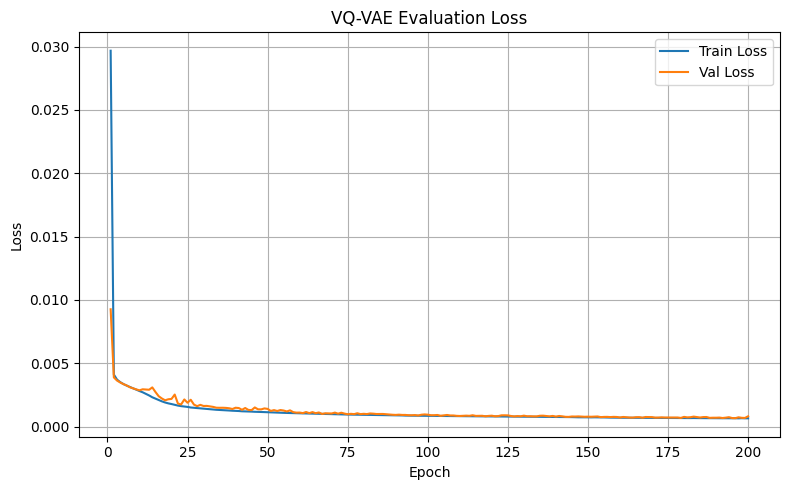

In [14]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss_hist, label="Train Loss")
plt.plot(epochs, val_loss_hist, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VQ-VAE Evaluation Loss")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

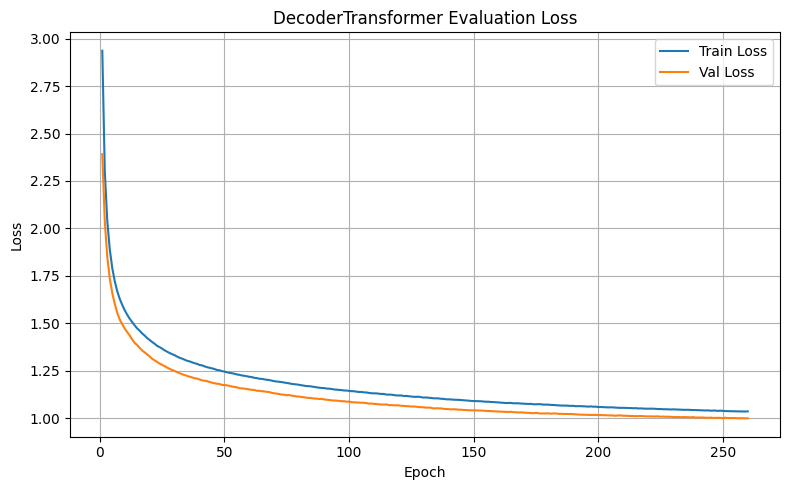

In [15]:
epochs = range(1, len(tr_train_loss_hist) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, tr_train_loss_hist, label="Train Loss")
plt.plot(epochs, tr_val_loss_hist, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DecoderTransformer Evaluation Loss")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [16]:
zr_true = zr_true_t.squeeze(1).cpu().numpy()         # [N, 128]
zr_generated = zr_generated_t.squeeze(1).cpu().numpy()  # [N, 128]

print("zr_true shape:", zr_true.shape)
print("zr_generated shape:", zr_generated.shape)

zr_true shape: (2000, 128)
zr_generated shape: (2000, 128)


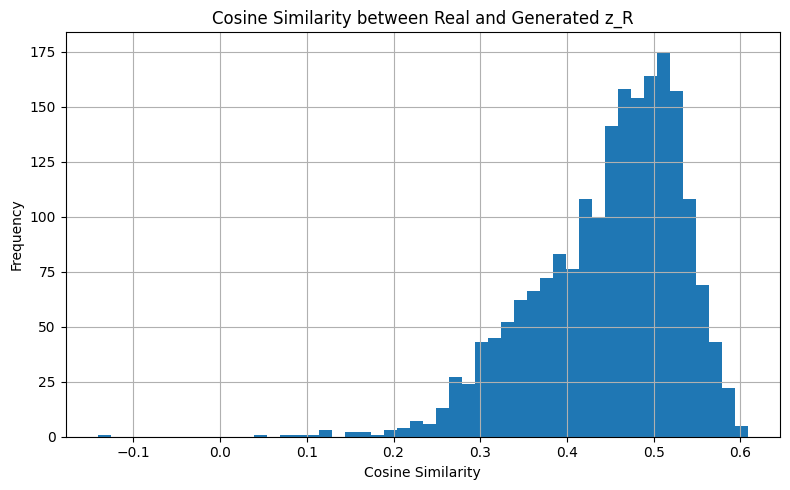

Mean cosine similarity: 0.4472547


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

cos_vals = []

for r, g in zip(zr_true, zr_generated):
    sim = cosine_similarity(r.reshape(1, -1), g.reshape(1, -1))[0][0]
    cos_vals.append(sim)

cos_vals = np.array(cos_vals)

plt.figure(figsize=(8,5))
plt.hist(cos_vals, bins=50)
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Cosine Similarity between Real and Generated z_R")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Mean cosine similarity:", cos_vals.mean())

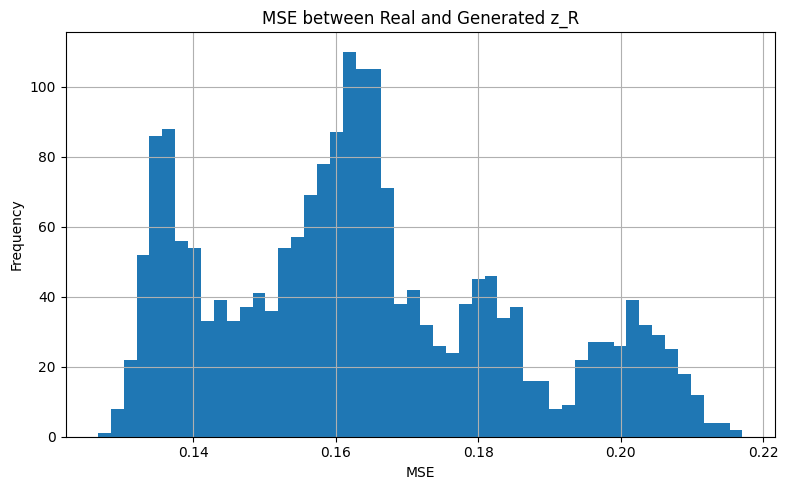

Mean MSE: 0.16398253


In [18]:
mse_vals = ((zr_true - zr_generated) ** 2).mean(axis=1)

plt.figure(figsize=(8,5))
plt.hist(mse_vals, bins=50)
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.title("MSE between Real and Generated z_R")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Mean MSE:", mse_vals.mean())

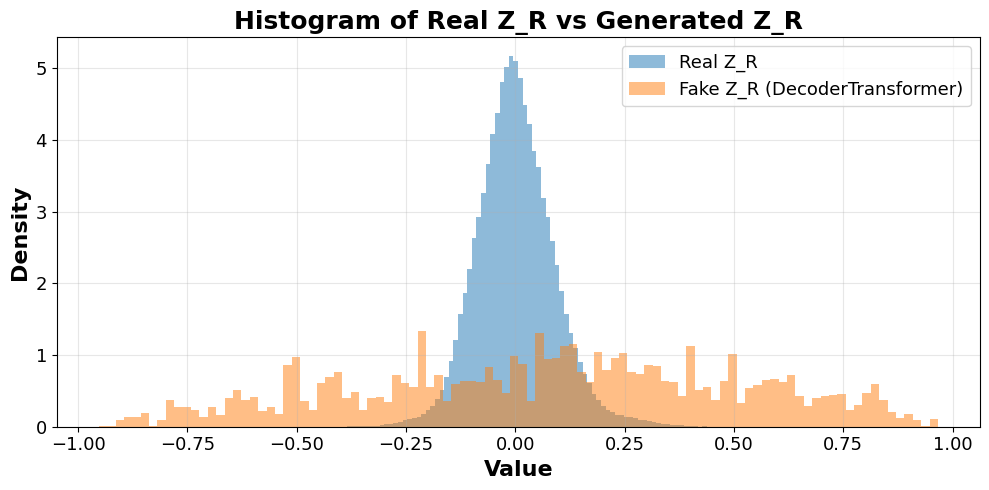

In [19]:
plt.figure(figsize=(10,5))

plt.hist(zr_true.reshape(-1),bins=100,alpha=0.5,label="Real Z_R",density=True)
plt.hist(zr_generated.reshape(-1),bins=100,alpha=0.5,label="Fake Z_R (DecoderTransformer)",density=True)
plt.title("Histogram of Real Z_R vs Generated Z_R",fontsize=18,fontweight="bold")
plt.xlabel("Value",fontsize=16,fontweight="bold")
plt.ylabel("Density",fontsize=16,fontweight="bold")

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=13)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

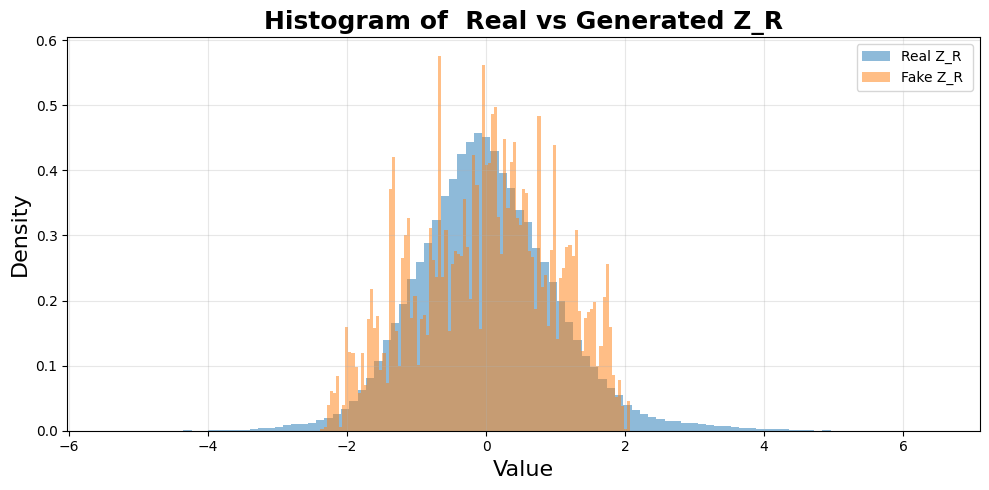

In [21]:

def normalize(z):
    return (z - z.mean()) / (z.std() + 1e-8)

zr_true_norm = normalize(zr_true)
zr_generated_norm = normalize(zr_generated)

plt.figure(figsize=(10,5))

plt.hist(zr_true_norm.reshape(-1), bins=100, alpha=0.5,
         label="Real Z_R", density=True)

plt.hist(zr_generated_norm.reshape(-1), bins=100, alpha=0.5,
         label="Fake Z_R ", density=True)

plt.title("Histogram of  Real vs Generated Z_R", fontsize=18, fontweight="bold")
plt.xlabel("Value", fontsize=16)
plt.ylabel("Density", fontsize=16)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()